# Basic FF Neural Network Analysis for the effects of weather to a days delays

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

In [3]:
file_name = "../../data/delays/subway/cleaned_data/cleaned_subway_data.csv"
weather_file_name = "../../data/weather/Toronto_City_Centre_2XUGG (43.63, -79.4).csv"

sub_data = pd.read_csv(file_name)

weather_data = pd.read_csv(weather_file_name)

In [4]:
sub_data["Time"] = pd.to_datetime(sub_data["Datetime"])

In [5]:
sub_data["date_only"] = pd.to_datetime(sub_data["Time"])
sub_data["date_only"] = sub_data["date_only"].dt.floor("1D")
sub_data_copy = sub_data

date_range = pd.date_range(start="2023-01-01", end="2024-12-31", freq="1D")
dummy = pd.DataFrame({'date_only': date_range})

sub_data = dummy.merge(sub_data, on='date_only', how='left')

# drop outliers (display these later)
super_delays = sub_data[sub_data["Min Delay"]>60].dropna()
super_delays = super_delays[super_delays["Min Delay"]<1000]
sub_data = sub_data[sub_data["Min Delay"]<=60] 

mean_sub_data = sub_data.groupby("date_only")[["Min Delay", "Min Gap"]].mean().reset_index()
mean_sub_data = mean_sub_data[mean_sub_data["date_only"] >= "2023-01-01"]
count_sub_data = sub_data.groupby("date_only")[["Min Delay", "Min Gap"]].count().reset_index()
count_sub_data = count_sub_data[count_sub_data["date_only"] >= "2023-01-01"]
super_means = super_delays.groupby("date_only")[["Min Delay", "Min Gap"]].mean().reset_index()

display(mean_sub_data)

display(weather_data)

,date_only,Min Delay,Min Gap
0,2023-01-01,2.906977,5.558140
1,2023-01-02,2.926829,5.219512
2,2023-01-03,2.883721,4.604651
3,2023-01-04,3.754098,5.377049
4,2023-01-05,2.088889,3.488889
...,...,...,...
726,2024-12-27,1.688312,2.584416
727,2024-12-28,1.390244,2.524390
728,2024-12-29,2.218750,3.187500
729,2024-12-30,1.613636,2.659091


,date,tavg,tmin,tmax,prcp,wdir,wspd
0,2023-01-01 0:00:00,2.5,1.5,3.3,0.3,234.0,9.1
1,2023-01-02 0:00:00,2.5,-2.0,5.5,0.0,260.0,6.8
2,2023-01-03 0:00:00,2.3,0.0,3.5,1.3,57.0,14.5
3,2023-01-04 0:00:00,3.0,2.6,3.7,25.1,66.0,17.8
4,2023-01-05 0:00:00,2.8,0.5,4.1,0.5,216.0,11.1
...,...,...,...,...,...,...,...
726,2024-12-27 0:00:00,1.2,-0.2,2.5,0.0,87.0,25.2
727,2024-12-28 0:00:00,5.4,2.4,9.2,1.0,176.0,19.0
728,2024-12-29 0:00:00,5.0,0.6,10.3,27.0,81.0,22.0
729,2024-12-30 0:00:00,4.6,2.9,9.3,2.4,238.0,36.8


In [38]:
class FFN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(FFN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size) 
        self.fc2 = nn.Linear(hidden_size, hidden_size) 
        self.fc3 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.relu(out)
        out = self.fc3(out)

        return out

In [39]:
input_size = 6
output_size = 2 # mean min delay, count of delay
hidden_size = 64
batch_size = 8

In [71]:
model = FFN(input_size, hidden_size, output_size)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [72]:
X = weather_data[weather_data.columns[1:]]
y1 = mean_sub_data['Min Delay']
y2 = count_sub_data["Min Delay"]
good_rows = X.notna().all(axis=1)

X = X[good_rows]
y1 = y1[good_rows]
y2 = y2[good_rows]

X = torch.tensor(X.values, dtype = torch.float32)
y = torch.stack([torch.tensor(y1.values, dtype = torch.float32),torch.tensor(y2.values, dtype = torch.float32)], dim = 1)

X_train = X[:-200]
y_train = y[:-200]

X_test = X[-200:]
y_test = y[-200:]

print(X.shape)
print(y.shape)

print(torch.isnan(X).any())
print(torch.isnan(y).any())

torch.Size([719, 6])
torch.Size([719, 2])
tensor(False)
tensor(False)


In [73]:
num_epochs = 1000

epochs = []
losses = []

for epoch in range(num_epochs):
    total_loss = 0
    for i in range(0, len(X_train), batch_size):
        x_batch = X_train[i:i+batch_size]
        y_batch = y_train[i:i+batch_size]

        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        total_loss += loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    epochs.append(epoch)
    losses.append(total_loss.item()/(len(X_train)/batch_size))

    print(f"Epoch: {epoch}, MSE: {loss}")

Epoch: 0, MSE: 205.34288024902344
Epoch: 1, MSE: 130.10061645507812
Epoch: 2, MSE: 92.76753997802734
Epoch: 3, MSE: 107.177490234375
Epoch: 4, MSE: 86.99790954589844
Epoch: 5, MSE: 88.48912811279297
Epoch: 6, MSE: 89.14503479003906
Epoch: 7, MSE: 94.06494140625
Epoch: 8, MSE: 92.78001403808594
Epoch: 9, MSE: 91.94844818115234
Epoch: 10, MSE: 88.90733337402344
Epoch: 11, MSE: 90.67713928222656
Epoch: 12, MSE: 84.75050354003906
Epoch: 13, MSE: 96.97434997558594
Epoch: 14, MSE: 88.70223236083984
Epoch: 15, MSE: 86.50709533691406
Epoch: 16, MSE: 92.82755279541016
Epoch: 17, MSE: 85.62345123291016
Epoch: 18, MSE: 79.96209716796875
Epoch: 19, MSE: 78.57487487792969
Epoch: 20, MSE: 78.69647216796875
Epoch: 21, MSE: 100.42814636230469
Epoch: 22, MSE: 87.33843994140625
Epoch: 23, MSE: 88.09345245361328
Epoch: 24, MSE: 99.35545349121094
Epoch: 25, MSE: 89.87386322021484
Epoch: 26, MSE: 84.5442886352539
Epoch: 27, MSE: 110.1236572265625
Epoch: 28, MSE: 141.06723022460938
Epoch: 29, MSE: 77.764541

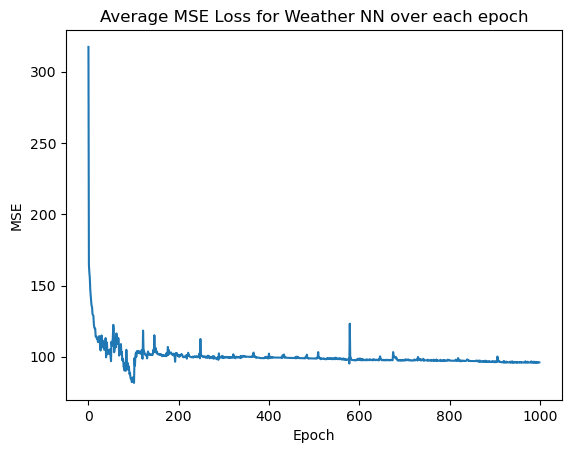

In [74]:
plt.plot(epochs, losses)
plt.title("Average MSE Loss for Weather NN over each epoch")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

In [75]:
model.eval() 
with torch.no_grad():
    predictions = model(X_test) 

mse = criterion(predictions, y_test.long())
print(f"Mean Squared Error on test set: {mse.item()}")

Mean Squared Error on test set: 87.92131042480469


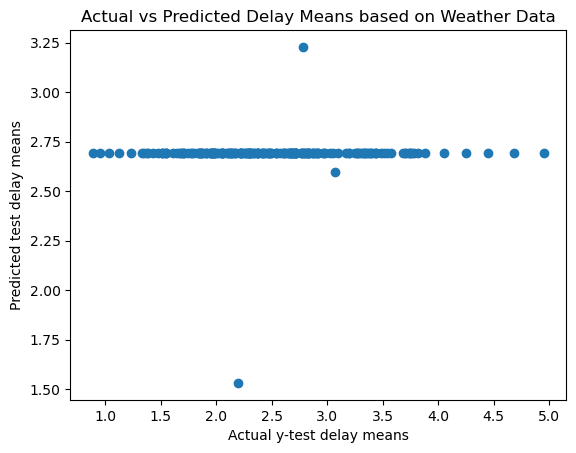

In [76]:
plt.scatter(y_test[:,0], predictions[:,0])
plt.title("Actual vs Predicted Delay Means based on Weather Data")
plt.xlabel("Actual y-test delay means")
plt.ylabel("Predicted test delay means")
plt.show()

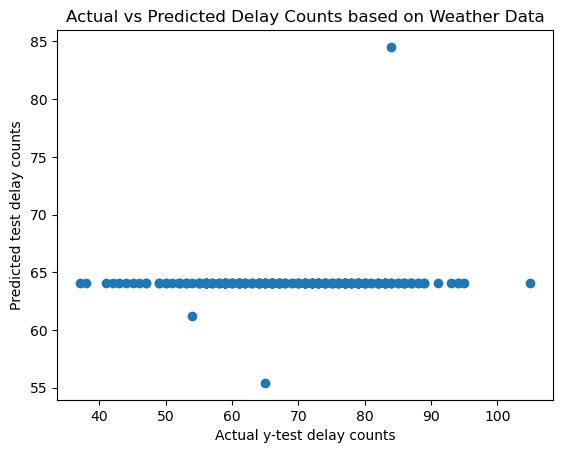

In [77]:
plt.scatter(y_test[:,1], predictions[:,1])
plt.title("Actual vs Predicted Delay Counts based on Weather Data")
plt.xlabel("Actual y-test delay counts")
plt.ylabel("Predicted test delay counts")
plt.show()

In [78]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test[:,0], predictions[:,0])
print("Mean R squared:", r2)

r2 = r2_score(y_test[:,1], predictions[:,1])
print("Count R squared:", r2)

Mean R squared: -0.06799340068726067
Count R squared: -0.14794106434075593
